In [10]:
from graph.higher_dim_graph import Graph
from graph.graph import restore_from_csv
import metrics.metrics as mtx
import pandas as pd
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import powerlaw
import os
import re
import prepare
from run_maltparser import annotate
from make_graph_en import build_en_graph
from make_graph_ru import build_ru_graph
from eng_rb_anaphora import resolve_anaphora_en
from ru_rb_anaphora import resolve_anaphora_ru
import nltk
from nltk.tokenize import sent_tokenize
import string
from tqdm import tqdm

# Download required NLTK data if not present
# nltk.download("punkt_tab")


# Prepare corpus

In [11]:
def get_all_txt_files(directory):
    """
    Get all .txt files from a directory and its subdirectories.
    
    Args:
        directory (str): The root directory to search in.
    
    Returns:
        list: A list of strings, each being the content of a .txt file.
    """
    txt_contents = []
    for root, dirs, files in os.walk(directory):
        for file in files:
            if file.endswith('.txt'):
                file_path = os.path.join(root, file)
                try:
                    with open(file_path, 'r', encoding='utf-8') as f:
                        content = f.read()
                        txt_contents.append(content)
                except Exception as e:
                    print(f"Error reading {file_path}: {e}")
    return txt_contents

In [12]:
def clean_angle_brackets(text):
    """
    Remove text enclosed in angle brackets <> from a string.
    
    Args:
        text (str): The input string.
    
    Returns:
        str: The cleaned string with angle bracket content removed.
    """
    return re.sub(r'<[^>]*>', '', text)

In [61]:
print(' Eng standard')
sum = 0
texsts_es = sorted(get_all_txt_files('corpus/eng_standard'), key=lambda x: len(x.split()))[:1000]
texsts_es = [' '.join(clean_angle_brackets(text).split()[:400]) for text in texsts_es]  # Truncate to first 400 words
for text in texsts_es:
    sum += len(text.split())
print(f"Number of files: {len(texsts_es)}")
print(f"Mean words in Eng standard: {sum / len(texsts_es) if texsts_es else 0}")

print('\n Ru standard')
sum = 0
texsts_rs = sorted(get_all_txt_files('corpus/ru_standard'), key=lambda x: len(x.split()))[:1000]
texsts_rs = [' '.join(clean_angle_brackets(text).split()[:700]) for text in texsts_rs]  # Truncate to first 500 words
for text in texsts_rs:
    sum += len(text.split())
print(f"Number of files: {len(texsts_rs)}")
print(f"Mean words in Ru standard: {sum / len(texsts_rs) if texsts_rs else 0}")

print('\n Eng learner')
sum = 0
texsts_el = sorted(get_all_txt_files('corpus/eng_non_standard'), key=lambda x: len(x.split()))[23000:24000]
texsts_el = [' '.join(clean_angle_brackets(text).split()[:400]) for text in texsts_el]  # Truncate to first 400 words
for text in texsts_el:
    sum += len(text.split())
print(f"Number of files: {len(texsts_el)}")
print(f"Mean words in Eng learner: {sum / len(texsts_el) if texsts_el else 0}")

print('\n Ru learner')
sum = 0
texsts_rl = sorted(get_all_txt_files('corpus/ru_non_standard'), key=lambda x: len(x.split()))[1896:]
texsts_rl = [clean_angle_brackets(text) for text in texsts_rl]  # Clean the texts
for text in texsts_rl:
    sum += len(text.split())
print(f"Number of files: {len(texsts_rl)}")
print(f"Mean words in Ru learner: {sum / len(texsts_rl) if texsts_rl else 0}")

 Eng standard
Number of files: 1000
Mean words in Eng standard: 399.427

 Ru standard
Number of files: 1000
Mean words in Ru standard: 385.431

 Eng learner
Number of files: 1000
Mean words in Eng learner: 394.187

 Ru learner
Number of files: 1000
Mean words in Ru learner: 385.806


In [62]:
def create_corpus_df(texts):
    """
    Create a DataFrame from a list of texts with columns 'text' and 'word_count'.
    
    Args:
        texts (list): List of strings, each being a text.
    
    Returns:
        pd.DataFrame: DataFrame with 'text' and 'word_count' columns.
    """
    word_counts = [len(text.split()) for text in texts]
    df = pd.DataFrame({'text': texts, 'word_count': word_counts})
    return df

# Create DataFrames for each balanced corpus
eng_standard_df = create_corpus_df(texsts_es)
eng_non_standard_df = create_corpus_df(texsts_el)
ru_standard_df = create_corpus_df(texsts_rs)
ru_non_standard_df = create_corpus_df(texsts_rl)

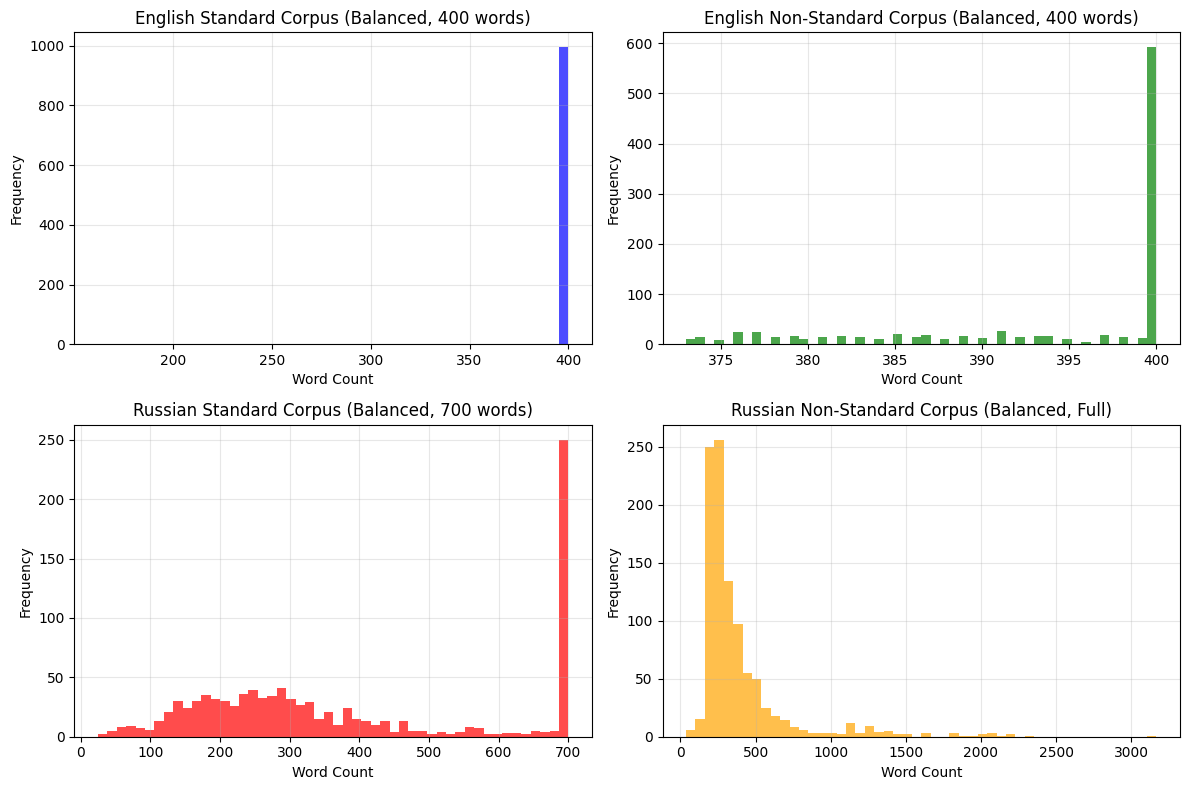

In [65]:
# Compute word counts for the balanced corpora
es_word_counts = [len(text.split()) for text in texsts_es]
el_word_counts = [len(text.split()) for text in texsts_el]
rs_word_counts = [len(text.split()) for text in texsts_rs]
rl_word_counts = [len(text.split()) for text in texsts_rl]

# For raw corpora
# es_word_counts = [len(text.split()) for text in get_all_txt_files('corpus/eng_standard')]
# el_word_counts = [len(text.split()) for text in get_all_txt_files('corpus/eng_non_standard')]
# rs_word_counts = [len(text.split()) for text in get_all_txt_files('corpus/ru_standard')]
# rl_word_counts = [len(text.split()) for text in get_all_txt_files('corpus/ru_non_standard')]

# Create 4 subplots for word count distributions
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# English Standard
axes[0, 0].hist(es_word_counts, bins=50, alpha=0.7, color='blue')
axes[0, 0].set_title('English Standard Corpus (Balanced, 400 words)')
axes[0, 0].set_xlabel('Word Count')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].grid(True, alpha=0.3)

# English Non-Standard (Learner)
axes[0, 1].hist(el_word_counts, bins=50, alpha=0.7, color='green')
axes[0, 1].set_title('English Non-Standard Corpus (Balanced, 400 words)')
axes[0, 1].set_xlabel('Word Count')
axes[0, 1].set_ylabel('Frequency')
axes[0, 1].grid(True, alpha=0.3)

# Russian Standard
axes[1, 0].hist(rs_word_counts, bins=50, alpha=0.7, color='red')
axes[1, 0].set_title('Russian Standard Corpus (Balanced, 700 words)')
axes[1, 0].set_xlabel('Word Count')
axes[1, 0].set_ylabel('Frequency')
axes[1, 0].grid(True, alpha=0.3)

# Russian Non-Standard (Learner)
axes[1, 1].hist(rl_word_counts, bins=50, alpha=0.7, color='orange')
axes[1, 1].set_title('Russian Non-Standard Corpus (Balanced, Full)')
axes[1, 1].set_xlabel('Word Count')
axes[1, 1].set_ylabel('Frequency')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Calculate metrics

In [28]:
def process_text_to_graph(text, lang):
    """
    Process a text to build a graph using the pipeline.
    
    Args:
        text (str): The input text.
        lang (str): Language ('en' or 'ru').
    
    Returns:
        Graph: The built graph object.
    """
    sentences = sent_tokenize(text)
    cleaned_sentences = []
    for s in sentences:
        s = s.strip().replace("\n", " ").replace("\t", " ").lower()
        cleaned_sentences.append("".join(ch for ch in s if ch not in (string.punctuation)))
    sentences = cleaned_sentences
    input_path = "input.conll"

    with open(input_path, "w") as f:
        for sent in sentences:
            f.write(f"# text = {sent}\n")
            conll_data = prepare.sentence_to_conllx(sent, lang=lang)
            f.write(conll_data)
            f.write("\n")

    annotate("input.conll", "output.conll", lang=lang)

    if lang == 'en':
        resolved_sentences = resolve_anaphora_en("output.conll")
    elif lang == 'ru':
        resolved_sentences = resolve_anaphora_ru("output.conll")

    if lang == 'en':
        g = build_en_graph(resolved_sentences)
    else:
        g = build_ru_graph(resolved_sentences)

    return g

In [29]:
def compute_metrics_for_df(df, lang):
    """
    Compute graph and classic metrics for all texts in a DataFrame.
    
    Args:
        df (pd.DataFrame): DataFrame with 'text' column.
        lang (str): Language ('en' or 'ru').
    
    Returns:
        pd.DataFrame: DataFrame with added metric columns.
    """
    graph_metrics_list = []
    classic_metrics_list = []
    
    for text in tqdm(df['text'], desc=f"Processing {lang} texts"):
        try:
            g = process_text_to_graph(text, lang)
            graph_metrics = mtx.calculate_metrics(g)
            graph_metrics_list.append(graph_metrics)
        except Exception as e:
            print(f"Error processing graph for text: {e}")
            # Add default values
            graph_metrics_list.append({k: 0 for k in ['num_vertices', 'num_edges', 'average_degree', 'density', 'average_clustering_coefficient', 'assortativity', 'connected_components', 'giant_component_size', 'average_shortest_path_length', 'diameter', 'average_degree_centrality', 'average_betweenness_centrality', 'average_closeness_centrality', 'average_eigenvector_centrality']})
        
        lemmas = mtx.get_lemmas(text, lang)
        tokens = mtx.get_tokens(text)

        classic = {
            'classic_average_word_length': mtx.average_word_length(tokens),
            'classic_ttr': mtx.calculate_ttr(lemmas, lang),
            'classic_mtld': mtx.calculate_mtld(lemmas, lang),
            'classic_syllable_count': mtx.syllables_count(text, lang),
            'classic_average_syllables_per_word': mtx.average_syllables_per_word(text, lang),
            'classic_t_score': mtx.calculate_t_score(lemmas),
            'classic_mi': mtx.calculate_mi(lemmas),
            'classic_logdice': mtx.calculate_logdice(lemmas)
        }
        classic_metrics_list.append(classic)
    
    # Add graph metrics columns
    for key in graph_metrics_list[0].keys():
        df[f'graph_{key}'] = [m[key] for m in graph_metrics_list]
    
    # Add classic metrics columns
    for key in classic_metrics_list[0].keys():
        df[key] = [m[key] for m in classic_metrics_list]
    
    return df

In [ ]:
# Compute metrics for each DataFrame
print("Computing metrics for English Standard...")
eng_standard_df = compute_metrics_for_df(eng_standard_df, 'en')

print("Computing metrics for English Non-Standard...")
eng_non_standard_df = compute_metrics_for_df(eng_non_standard_df, 'en')

print("Computing metrics for Russian Standard...")
ru_standard_df = compute_metrics_for_df(ru_standard_df, 'ru')

print("Computing metrics for Russian Non-Standard...")
ru_non_standard_df = compute_metrics_for_df(ru_non_standard_df, 'ru')

print("Metrics computation completed.")

In [35]:
eng_standard_df.to_pickle("eng_standard_df_test.pkl")
eng_standard_df.to_csv("eng_standard_df_test.csv", index=False)

eng_non_standard_df.to_pickle("eng_non_standard_df_test.pkl")
eng_non_standard_df.to_csv("eng_non_standard_df_test.csv", index=False)

ru_standard_df.to_pickle("ru_standard_df_test.pkl")
ru_standard_df.to_csv("ru_standard_df_test.csv", index=False)

# ru_non_standard_df.to_pickle("ru_non_standard_df_test.pkl")
# ru_non_standard_df.to_csv("ru_non_standard_df_test.csv", index=False)

In [55]:
def correlation_analysis(df, df_name):
    """
    Perform correlation analysis between graph and classic metrics in a DataFrame.
    
    Args:
        df (pd.DataFrame): DataFrame containing graph and classic metric columns.
        df_name (str): Name of the DataFrame for labeling purposes.
    
    Returns:
        pd.DataFrame: Correlation matrix between graph and classic metrics.
    """
    metric_cols = [col for col in df.columns if col.startswith('graph_') or col.startswith('classic_')]
    corr = df[metric_cols].corr()

    graph_cols = [col for col in metric_cols if col.startswith('graph_')]
    classic_cols = [col for col in metric_cols if col.startswith('classic_')]

    corr_between = corr.loc[graph_cols, classic_cols]
    print(f'Graph vs Classic metric correlations for {df_name}:')
    print('-' * 80)
    print(corr_between.round(3))

    print('\nSummary:')
    print(f"Mean absolute correlation: {corr_between.abs().values.flatten().mean():.3f}")
    print(f"Max absolute correlation: {corr_between.abs().values.flatten().max():.3f}")
    print(f"Min absolute correlation: {corr_between.abs().values.flatten().min():.3f}")

    # Heatmap
    plt.figure(figsize=(10, 8))
    plt.imshow(corr_between, aspect='auto', cmap='coolwarm', vmin=-1, vmax=1)
    plt.colorbar(label='Correlation')
    plt.xticks(ticks=np.arange(len(classic_cols)), labels=classic_cols, rotation=45, ha='right')
    plt.yticks(ticks=np.arange(len(graph_cols)), labels=graph_cols)
    plt.title(f'Heatmap of Graph vs Classic Metric Correlations ({df_name})')
    
    # Добавление текстовых значений корреляции на график
    for i in range(len(graph_cols)):
        for j in range(len(classic_cols)):
            val = corr_between.iloc[i, j]
            # Выбор цвета текста в зависимости от значения (для читаемости на темном/светлом фоне)
            text_color = "white" if abs(val) > 0.5 else "black"
            plt.text(j, i, f"{val:.2f}", ha="center", va="center", color=text_color)

    plt.tight_layout()
    plt.show()

    # Optionally display top correlations
    corr_flat = corr_between.abs().stack().sort_values(ascending=False)
    print('\nTop 10 strongest correlations:')
    for i, ((g_col, c_col), val) in enumerate(corr_flat.head(10).items(), start=1):
        print(f"{i}. {g_col} <-> {c_col}: {corr_between.loc[g_col, c_col]:.3f}")
        
    return corr_between

# Analysing metrics

## Diff DFs

Graph vs Classic metric correlations for English Standard:
--------------------------------------------------------------------------------
                                      classic_average_word_length  \
graph_num_vertices                                          0.100   
graph_num_edges                                             0.098   
graph_average_degree                                       -0.005   
graph_density                                              -0.085   
graph_average_clustering_coefficient                        0.035   
graph_assortativity                                         0.022   
graph_connected_components                                  0.038   
graph_giant_component_size                                  0.081   
graph_average_shortest_path_length                          0.014   
graph_diameter                                              0.018   
graph_average_degree_centrality                            -0.080   
graph_average_betweenness_centra

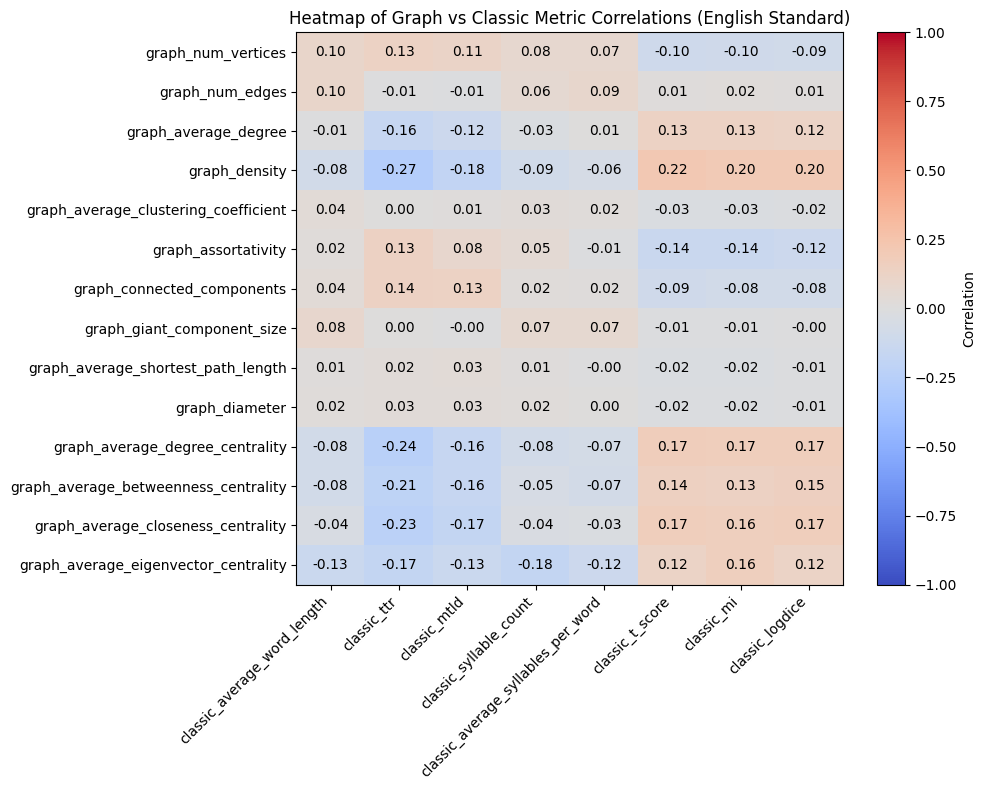


Top 10 strongest correlations:
1. graph_density <-> classic_ttr: -0.266
2. graph_average_degree_centrality <-> classic_ttr: -0.235
3. graph_average_closeness_centrality <-> classic_ttr: -0.233
4. graph_density <-> classic_t_score: 0.215
5. graph_average_betweenness_centrality <-> classic_ttr: -0.209
6. graph_density <-> classic_mi: 0.202
7. graph_density <-> classic_logdice: 0.200
8. graph_density <-> classic_mtld: -0.183
9. graph_average_eigenvector_centrality <-> classic_syllable_count: -0.179
10. graph_average_closeness_centrality <-> classic_mtld: -0.175


,classic_average_word_length,classic_ttr,classic_mtld,classic_syllable_count,classic_average_syllables_per_word,classic_t_score,classic_mi,classic_logdice
graph_num_vertices,0.100392,0.131334,0.113172,0.075448,0.074025,-0.101710,-0.097379,-0.092744
graph_num_edges,0.098227,-0.005180,-0.011353,0.058633,0.092607,0.009491,0.016127,0.011097
graph_average_degree,-0.005162,-0.161022,-0.120407,-0.027089,0.006785,0.128306,0.128145,0.124028
graph_density,-0.084827,-0.265997,-0.183105,-0.090449,-0.061464,0.215140,0.202462,0.199795
graph_average_clustering_coefficient,0.035427,0.001723,0.014999,0.025096,0.019096,-0.026624,-0.030312,-0.023387
graph_assortativity,0.021926,0.133256,0.082523,0.053923,-0.013642,-0.137078,-0.139607,-0.121488
graph_connected_components,0.038284,0.140134,0.127612,0.020022,0.015476,-0.094271,-0.084936,-0.083836
graph_giant_component_size,0.080778,0.002740,-0.001274,0.066296,0.069585,-0.013274,-0.010852,-0.004262
graph_average_shortest_path_length,0.013642,0.024698,0.033730,0.011734,-0.004174,-0.023671,-0.024840,-0.013820
graph_diameter,0.017902,0.028207,0.027276,0.021240,0.000711,-0.021174,-0.022815,-0.009728


In [56]:
eng_s_df = pd.read_pickle("eng_standard.pkl")
correlation_analysis(eng_s_df, 'English Standard')

Graph vs Classic metric correlations for Russian Standard:
--------------------------------------------------------------------------------
                                      classic_average_word_length  \
graph_num_vertices                                          0.256   
graph_num_edges                                             0.131   
graph_average_degree                                       -0.069   
graph_density                                              -0.176   
graph_average_clustering_coefficient                       -0.178   
graph_assortativity                                         0.044   
graph_connected_components                                  0.219   
graph_giant_component_size                                  0.210   
graph_average_shortest_path_length                          0.114   
graph_diameter                                              0.120   
graph_average_degree_centrality                            -0.170   
graph_average_betweenness_centra

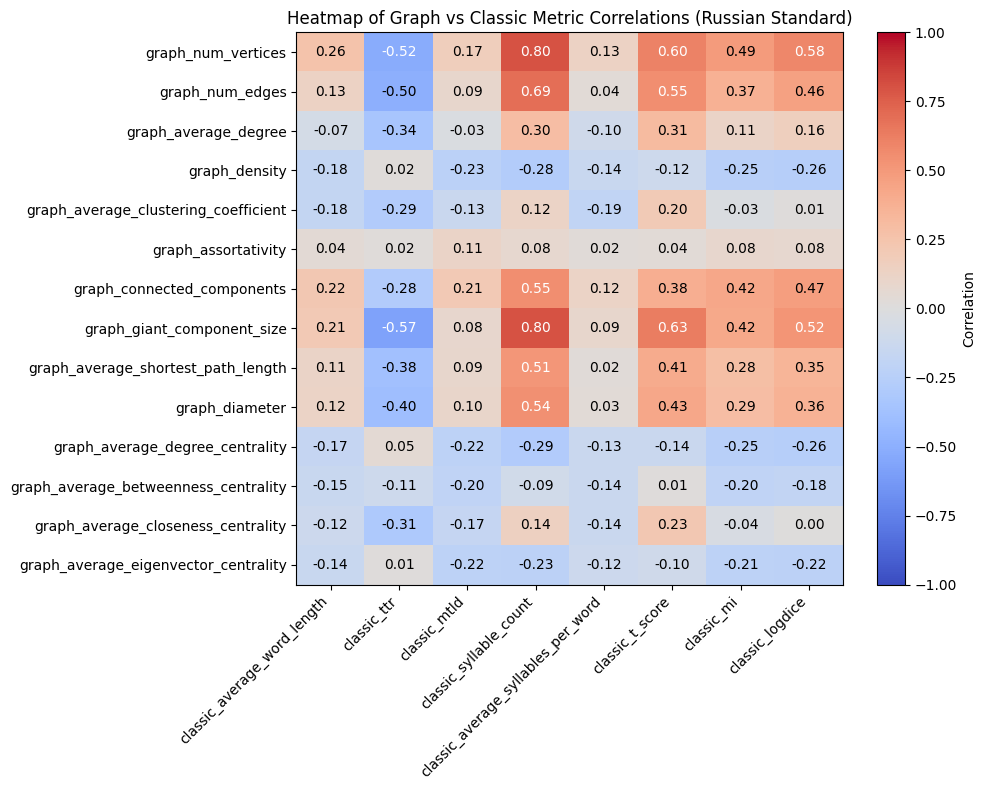


Top 10 strongest correlations:
1. graph_num_vertices <-> classic_syllable_count: 0.804
2. graph_giant_component_size <-> classic_syllable_count: 0.799
3. graph_num_edges <-> classic_syllable_count: 0.688
4. graph_giant_component_size <-> classic_t_score: 0.629
5. graph_num_vertices <-> classic_t_score: 0.603
6. graph_num_vertices <-> classic_logdice: 0.579
7. graph_giant_component_size <-> classic_ttr: -0.575
8. graph_num_edges <-> classic_t_score: 0.553
9. graph_connected_components <-> classic_syllable_count: 0.550
10. graph_diameter <-> classic_syllable_count: 0.542


,classic_average_word_length,classic_ttr,classic_mtld,classic_syllable_count,classic_average_syllables_per_word,classic_t_score,classic_mi,classic_logdice
graph_num_vertices,0.255810,-0.516941,0.169238,0.804457,0.125005,0.603040,0.486759,0.578805
graph_num_edges,0.131323,-0.497805,0.091519,0.687548,0.038589,0.553104,0.372156,0.459459
graph_average_degree,-0.068740,-0.336069,-0.027430,0.296315,-0.100941,0.310747,0.111024,0.162860
graph_density,-0.176089,0.019746,-0.228863,-0.275406,-0.141325,-0.115946,-0.247823,-0.262115
graph_average_clustering_coefficient,-0.177843,-0.286801,-0.134069,0.117470,-0.190333,0.201770,-0.029298,0.010439
graph_assortativity,0.043738,0.018793,0.114671,0.077825,0.024263,0.037359,0.079017,0.077267
graph_connected_components,0.219326,-0.281520,0.209281,0.550112,0.123269,0.384330,0.422984,0.471971
graph_giant_component_size,0.209843,-0.574700,0.081632,0.799190,0.088100,0.629088,0.415743,0.517607
graph_average_shortest_path_length,0.114408,-0.381763,0.092399,0.511530,0.024472,0.405134,0.281888,0.348515
graph_diameter,0.119901,-0.398338,0.099433,0.541920,0.033752,0.425583,0.289873,0.359391


In [57]:
ru_s_df = pd.read_pickle("ru_standard.pkl")
correlation_analysis(ru_s_df, 'Russian Standard')

Graph vs Classic metric correlations for English Non-Standard:
--------------------------------------------------------------------------------
                                      classic_average_word_length  \
graph_num_vertices                                          0.071   
graph_num_edges                                             0.095   
graph_average_degree                                        0.041   
graph_density                                              -0.017   
graph_average_clustering_coefficient                        0.032   
graph_assortativity                                         0.081   
graph_connected_components                                  0.007   
graph_giant_component_size                                  0.063   
graph_average_shortest_path_length                          0.043   
graph_diameter                                              0.057   
graph_average_degree_centrality                            -0.021   
graph_average_betweenness_ce

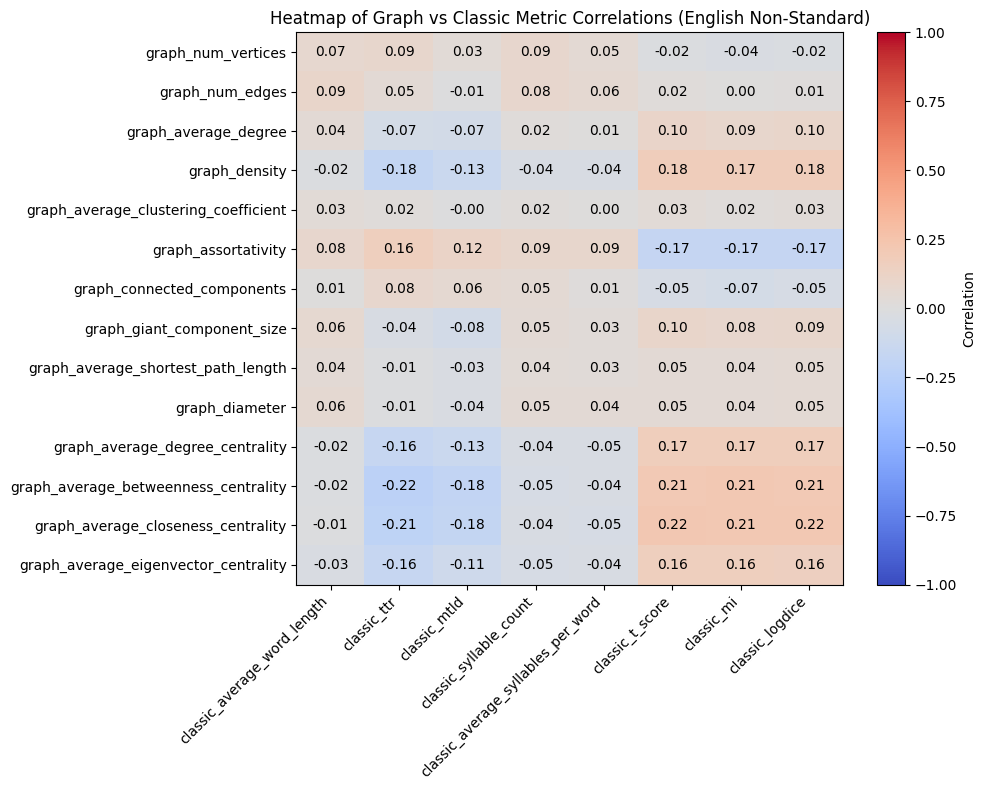


Top 10 strongest correlations:
1. graph_average_betweenness_centrality <-> classic_ttr: -0.223
2. graph_average_closeness_centrality <-> classic_t_score: 0.222
3. graph_average_closeness_centrality <-> classic_logdice: 0.219
4. graph_average_closeness_centrality <-> classic_mi: 0.214
5. graph_average_betweenness_centrality <-> classic_mi: 0.212
6. graph_average_closeness_centrality <-> classic_ttr: -0.210
7. graph_average_betweenness_centrality <-> classic_logdice: 0.210
8. graph_average_betweenness_centrality <-> classic_t_score: 0.209
9. graph_average_betweenness_centrality <-> classic_mtld: -0.180
10. graph_density <-> classic_ttr: -0.179


,classic_average_word_length,classic_ttr,classic_mtld,classic_syllable_count,classic_average_syllables_per_word,classic_t_score,classic_mi,classic_logdice
graph_num_vertices,0.070908,0.087957,0.034118,0.085202,0.050934,-0.019630,-0.038982,-0.023627
graph_num_edges,0.094618,0.045782,-0.006747,0.081040,0.055197,0.020880,0.002061,0.014246
graph_average_degree,0.041235,-0.067170,-0.073550,0.021965,0.007254,0.102624,0.090944,0.098236
graph_density,-0.017288,-0.179218,-0.131492,-0.042023,-0.042809,0.177995,0.174436,0.175530
graph_average_clustering_coefficient,0.031809,0.016094,-0.001420,0.022490,0.002215,0.033495,0.022595,0.031109
graph_assortativity,0.081213,0.161347,0.115786,0.089740,0.087375,-0.166950,-0.167672,-0.166370
graph_connected_components,0.006521,0.083406,0.059217,0.047759,0.009788,-0.050174,-0.067378,-0.051695
graph_giant_component_size,0.063223,-0.041551,-0.076057,0.045272,0.025773,0.096354,0.083636,0.093565
graph_average_shortest_path_length,0.042806,-0.009518,-0.034116,0.038689,0.026543,0.045616,0.040806,0.047237
graph_diameter,0.056627,-0.009499,-0.035965,0.045946,0.039396,0.046113,0.043162,0.047669


In [58]:
eng_ns_df = pd.read_pickle("eng_non_standard.pkl")
correlation_analysis(eng_ns_df, 'English Non-Standard')

Graph vs Classic metric correlations for Russian Non-Standard:
--------------------------------------------------------------------------------
                                      classic_average_word_length  \
graph_num_vertices                                          0.161   
graph_num_edges                                             0.153   
graph_average_degree                                       -0.021   
graph_density                                              -0.007   
graph_average_clustering_coefficient                       -0.135   
graph_assortativity                                         0.041   
graph_connected_components                                  0.084   
graph_giant_component_size                                  0.170   
graph_average_shortest_path_length                          0.056   
graph_diameter                                              0.086   
graph_average_degree_centrality                             0.012   
graph_average_betweenness_ce

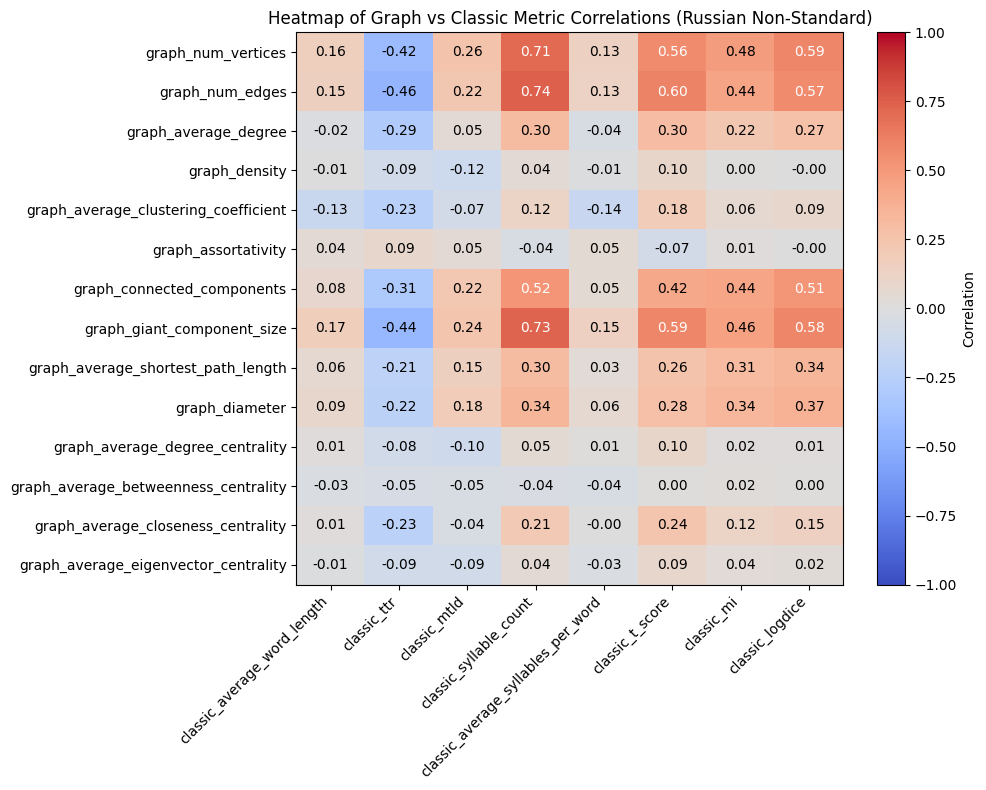


Top 10 strongest correlations:
1. graph_num_edges <-> classic_syllable_count: 0.744
2. graph_giant_component_size <-> classic_syllable_count: 0.732
3. graph_num_vertices <-> classic_syllable_count: 0.706
4. graph_num_edges <-> classic_t_score: 0.602
5. graph_num_vertices <-> classic_logdice: 0.591
6. graph_giant_component_size <-> classic_t_score: 0.589
7. graph_giant_component_size <-> classic_logdice: 0.579
8. graph_num_edges <-> classic_logdice: 0.569
9. graph_num_vertices <-> classic_t_score: 0.563
10. graph_connected_components <-> classic_syllable_count: 0.516


,classic_average_word_length,classic_ttr,classic_mtld,classic_syllable_count,classic_average_syllables_per_word,classic_t_score,classic_mi,classic_logdice
graph_num_vertices,0.161440,-0.415873,0.257301,0.705935,0.134615,0.563464,0.480198,0.591434
graph_num_edges,0.153035,-0.457115,0.222848,0.744053,0.132609,0.601726,0.444422,0.568648
graph_average_degree,-0.020572,-0.290343,0.046416,0.299841,-0.040610,0.295116,0.223515,0.266752
graph_density,-0.007173,-0.085447,-0.116508,0.042786,-0.014881,0.095160,0.003884,-0.002886
graph_average_clustering_coefficient,-0.134804,-0.234953,-0.074470,0.120860,-0.143071,0.184630,0.055127,0.088708
graph_assortativity,0.040666,0.090394,0.046829,-0.042930,0.047409,-0.072321,0.008804,-0.000668
graph_connected_components,0.083648,-0.310598,0.216957,0.516414,0.051001,0.420427,0.436241,0.509381
graph_giant_component_size,0.170054,-0.441479,0.240946,0.732438,0.147295,0.588634,0.458462,0.578687
graph_average_shortest_path_length,0.055933,-0.212349,0.154624,0.300256,0.033557,0.255014,0.311837,0.340442
graph_diameter,0.086096,-0.222090,0.180492,0.340278,0.064617,0.278902,0.335046,0.370896


In [59]:
ru_ns_df = pd.read_pickle("ru_non_standard.pkl")
correlation_analysis(ru_ns_df, 'Russian Non-Standard')

## One DF

In [52]:
df = pd.read_pickle("full_corpus_metrics.pkl")
df

,text,label,lang,num_vertices,num_edges,average_degree,density,average_clustering_coefficient,assortativity,connected_components,giant_component_size,average_shortest_path_length,diameter,average_degree_centrality,average_betweenness_centrality,average_closeness_centrality,average_eigenvector_centrality
0,MICUSP Version 1.0 - PHI.G0.06.5 - Philosophy ...,eng_standard,en,57,31,1.087719,0.019424,0.000000,-0.113636,34,11,2.545455,4,0.015664,0.001196,0.024905,0.051732
1,Jessica is 14 and lives with her mum and siste...,eng_standard,en,57,31,1.087719,0.019424,0.000000,-0.113636,34,11,2.545455,4,0.015664,0.001196,0.024905,0.051732
2,MICUSP Version 1.0 - CLS.G0.04.1 - History & C...,eng_standard,en,82,125,3.048780,0.037639,0.277696,-0.102438,22,61,4.000546,10,0.029810,0.020668,0.144050,0.059455
3,"The poem, or song, concerns a Lady's indecisio...",eng_standard,en,75,107,2.853333,0.038559,0.265132,-0.092083,11,60,5.798305,14,0.032432,0.041930,0.115093,0.047594
4,Aims:To measure experimentally the enthalpy of...,eng_standard,en,72,109,3.027778,0.042645,0.160935,0.244378,16,52,3.927602,9,0.034038,0.021702,0.139473,0.055045
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2916,Антибиотики: история открытия и использования...,ru_learner,ru,263,413,3.140684,0.011987,0.095970,-0.093738,34,217,4.048899,10,0.010855,0.007946,0.174730,0.030745
2917,Антибиотики: история открытия и использования...,ru_learner,ru,274,425,3.102190,0.011363,0.090645,-0.094884,37,224,4.043362,10,0.010267,0.007472,0.171774,0.029878
2918,Антибиотики: история открытия и использования...,ru_learner,ru,275,428,3.112727,0.011360,0.083096,-0.081734,38,224,4.134970,10,0.010139,0.007613,0.167169,0.030673
2919,Антибиотики: история открытия и использования...,ru_learner,ru,268,773,5.768657,0.021605,0.113486,-0.039830,28,226,3.337109,9,0.018223,0.006245,0.220243,0.034004


In [69]:
def correlation_analysis_groups(df, df_name, group1_cols, group2_cols):
    """
    Строит матрицу корреляций между двумя заданными группами метрик.
    """
    # Оставляем только те колонки, которые реально существуют в датафрейме
    g1_valid = [col for col in group1_cols if col in df.columns]
    g2_valid = [col for col in group2_cols if col in df.columns]

    if not g1_valid or not g2_valid:
        print(f"\n[!] Пропуск {df_name}: не найдены колонки для одной из групп.")
        return None

    # Оставляем только числовые данные для расчетов
    numeric_df = df.select_dtypes(include=[np.number])
    
    # Вычисляем полную корреляцию и вырезаем нужный кусок
    corr = numeric_df.corr()
    
    # Проверка, остались ли нужные колонки после фильтрации на числа
    g1_final = [col for col in g1_valid if col in corr.columns]
    g2_final = [col for col in g2_valid if col in corr.columns]
    
    if not g1_final or not g2_final:
        print(f"\n[!] Пропуск {df_name}: после проверки на числа списки колонок опустели.")
        return None

    corr_between = corr.loc[g1_final, g2_final]

    if corr_between.empty or corr_between.isna().all().all():
         print(f"\n[!] Пропуск {df_name}: данные пустые или константные.")
         return None

    print(f'Correlation between Group 1 and Group 2 for {df_name}:')
    print('-' * 80)
    print(corr_between.round(3))

    print('\nSummary:')
    print(f"Mean absolute correlation: {corr_between.abs().values.flatten().mean():.3f}")
    print(f"Max absolute correlation: {corr_between.abs().values.flatten().max():.3f}")
    print(f"Min absolute correlation: {corr_between.abs().values.flatten().min():.3f}")

    # Heatmap
    plt.figure(figsize=(10, 8))
    plt.imshow(corr_between, aspect='auto', cmap='coolwarm', vmin=-1, vmax=1)
    plt.colorbar(label='Correlation')
    
    plt.xticks(ticks=np.arange(len(g2_final)), labels=g2_final, rotation=45, ha='right')
    plt.yticks(ticks=np.arange(len(g1_final)), labels=g1_final)
    plt.title(f'Heatmap: Group 1 vs Group 2 ({df_name})')
    
    # Отрисовка значений
    for i in range(len(g1_final)):
        for j in range(len(g2_final)):
            val = corr_between.iloc[i, j]
            if not np.isnan(val):
                text_color = "white" if abs(val) > 0.5 else "black"
                plt.text(j, i, f"{val:.2f}", ha="center", va="center", color=text_color)

    plt.tight_layout()
    plt.show()

    # Топ-10 корреляций между группами
    corr_flat = corr_between.abs().stack().sort_values(ascending=False)
    print('\nTop 10 strongest correlations between groups:')
    for i, ((g1_col, g2_col), val) in enumerate(corr_flat.head(10).items(), start=1):
        orig_val = corr_between.loc[g1_col, g2_col]
        print(f"{i}. {g1_col} <-> {g2_col}: {orig_val:.3f}")
        
    return corr_between

In [71]:
group_a = [
    'num_vertices', 'num_edges', 'average_degree', 
    'density', 'average_clustering_coefficient', 
    'assortativity', 'connected_components', 'giant_component_size',
    'average_shortest_path_length', 'diameter', 
    'average_degree_centrality', 'average_betweenness_centrality', 
    'average_closeness_centrality', 'average_eigenvector_centrality'
]

group_b = [
    'average_word_length', 'ttr', 'mtld', 'syllable_count', 'average_syllables_per_word',
    't_score', 'mi', 'logdice'
]

# Убираем возможный мусор
df = df.dropna(subset=['label'])

for label_name, group_df in df.groupby('label'):
    print(f"\nЗапуск анализа для корпуса: {label_name}")
    correlation_analysis_groups(
        df=group_df, 
        df_name=f"Corpus {label_name}",
        group1_cols=group_a,
        group2_cols=group_b
    )
    print("=" * 80)


Запуск анализа для корпуса: eng_learner

[!] Пропуск Corpus eng_learner: не найдены колонки для одной из групп.

Запуск анализа для корпуса: eng_standard

[!] Пропуск Corpus eng_standard: не найдены колонки для одной из групп.

Запуск анализа для корпуса: ru_learner

[!] Пропуск Corpus ru_learner: не найдены колонки для одной из групп.

Запуск анализа для корпуса: ru_standard

[!] Пропуск Corpus ru_standard: не найдены колонки для одной из групп.
